Sonal Ambhore (CS23164)

In [1]:
import os
print(os.listdir())

['.config', 'Developer_Performance_dataset_1000.csv', 'sample_data']


In [2]:
from google.colab import files
uploaded = files.upload()

Saving Developer_Performance_dataset_1000.csv to Developer_Performance_dataset_1000 (1).csv


In [3]:
import os
print(os.listdir())

['.config', 'Developer_Performance_dataset_1000.csv', 'Developer_Performance_dataset_1000 (1).csv', 'sample_data']


In [4]:
import pandas as pd
df = pd.read_csv("/content/Developer_Performance_dataset_1000.csv")
df.head()

,Hours_Coding,Lines_of_Code,Bugs_Found,Bugs_Fixed,AI_Usage_Hours,Sleep_Hours,Cognitive_Load,Coffee_Intake,Stress_Level,Task_Duration_Hours,Commits,Errors,Task_Success_Rate
0,7,416,9,7,6,5.9,92,7,99,10.5,20,3,34
1,4,269,16,13,5,5.1,85,2,100,9.5,17,8,36
2,11,439,3,0,2,6.2,38,2,55,18.3,35,2,79
3,8,472,15,9,4,4.2,26,5,30,12.6,28,4,94
4,5,265,19,16,5,8.1,82,6,82,7.0,25,9,33


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Hours_Coding         1000 non-null   int64  
 1   Lines_of_Code        1000 non-null   int64  
 2   Bugs_Found           1000 non-null   int64  
 3   Bugs_Fixed           1000 non-null   int64  
 4   AI_Usage_Hours       1000 non-null   int64  
 5   Sleep_Hours          1000 non-null   float64
 6   Cognitive_Load       1000 non-null   int64  
 7   Coffee_Intake        1000 non-null   int64  
 8   Stress_Level         1000 non-null   int64  
 9   Task_Duration_Hours  1000 non-null   float64
 10  Commits              1000 non-null   int64  
 11  Errors               1000 non-null   int64  
 12  Task_Success_Rate    1000 non-null   int64  
dtypes: float64(2), int64(11)
memory usage: 101.7 KB


In [6]:
print(df.columns)

Index(['Hours_Coding', 'Lines_of_Code', 'Bugs_Found', 'Bugs_Fixed',
       'AI_Usage_Hours', 'Sleep_Hours', 'Cognitive_Load', 'Coffee_Intake',
       'Stress_Level', 'Task_Duration_Hours', 'Commits', 'Errors',
       'Task_Success_Rate'],
      dtype='object')


In [7]:
X = df.drop("Task_Success_Rate", axis=1)
y = df["Task_Success_Rate"]

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [10]:
y_pred = model.predict(X_test)

In [11]:
from sklearn.metrics import r2_score, mean_squared_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.8775122999916811
MSE: 49.62


In [12]:
depths = [2, 4, 6, 8, 10, 15]
r2_scores = []

for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred))

print(r2_scores)

[0.8275243775547128, 0.9090065042538732, 0.9185799214046445, 0.8890602069732483, 0.8792095354615197, 0.8775122999916811]


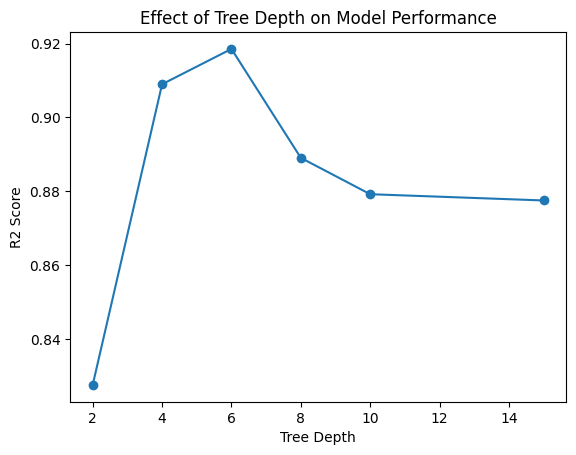

In [13]:
import matplotlib.pyplot as plt

plt.plot(depths, r2_scores, marker='o')
plt.xlabel("Tree Depth")
plt.ylabel("R2 Score")
plt.title("Effect of Tree Depth on Model Performance")
plt.show()

In [14]:
criteria = ["squared_error", "absolute_error"]

for crit in criteria:
    model = DecisionTreeRegressor(
        criterion=crit,
        max_depth=6,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("\nCriterion:", crit)
    print("R2 Score:", r2_score(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))


Criterion: squared_error
R2 Score: 0.9185799214046445
MSE: 32.98342853712783

Criterion: absolute_error
R2 Score: 0.8995499650828594
MSE: 40.6925
